# Notebook 4 — Patient Similarity Using a Multi-Omics Kernel

**Use case:** Patient similarity  
**Dataset:** TCGA-BRCA frozen cohort  
**Patients:** 617 primary tumour samples / 617 unique patients  
**Modalities:** RNA-seq (1,000 genes) · miRNA (300 miRNAs) · DNA methylation (1,000 CpGs)  
**Method:** RBF/Gaussian patient-similarity kernels with equal-weight multi-omics integration  
**Runtime target:** under 2–3 minutes on CPU

---

## Scientific question

> **Which TCGA-BRCA patients have similar molecular profiles across multiple omics layers?**

Patient similarity asks which patients are close to one another in molecular feature space. Kernel methods provide a convenient way to represent **nonlinear similarity** without forcing all modalities into one linear feature space.

For each modality, we:

1. Treat each patient as a point in that modality's feature space.
2. Use an RBF/Gaussian kernel to convert pairwise distances into similarities.
3. Obtain a patient × patient similarity matrix.
4. Integrate the three matrices into a multi-omics patient-similarity representation.
5. Identify nearest molecular neighbours and visualize the structure.

PAM50 is used only at the end as an external post-hoc biological reference.

---
## 1. Load the Frozen Cohort and Processed Matrices

Notebook 4 uses only files already produced by Notebooks 1–3. It does not reload raw TCGA data or download anything new.

---
## Conceptual Introduction — Patient Similarity

Patient similarity methods represent each patient using their molecular measurements and identify patients with similar multi-omics profiles. Instead of predicting a predefined label, the model asks whether patients naturally form groups or neighbourhoods based on their molecular characteristics.

Here, RNA-seq, miRNA, and methylation are combined through an integrated patient-level similarity representation. We then calculate patient–patient similarity and construct a k-nearest-neighbour graph. PAM50 is added only afterward as an external reference for biological interpretation.

In [16]:
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel, pairwise_distances
from sklearn.decomposition import KernelPCA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

NOTEBOOK_DIR = Path(".").resolve()
PROJECT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIGURE_DIR = PROCESSED_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_DIR}")
print(f"Processed data: {PROCESSED_DIR}")
print(f"Random seed: {SEED}")

Project root: C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop
Processed data: C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop\data\processed
Random seed: 42


In [2]:
paths = {
    "cohort": PROCESSED_DIR / "TCGA_BRCA_cohort_metadata.tsv",
    "rna": PROCESSED_DIR / "TCGA_BRCA_RNA_selected.tsv",
    "mirna": PROCESSED_DIR / "TCGA_BRCA_miRNA_selected.tsv",
    "methylation": PROCESSED_DIR / "TCGA_BRCA_methylation_selected.tsv",
}
for name, path in paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing required processed file: {path}")

cohort = pd.read_csv(paths["cohort"], sep="\t", index_col="sample_id")
rna = pd.read_csv(paths["rna"], sep="\t", index_col=0)
mirna = pd.read_csv(paths["mirna"], sep="\t", index_col=0)
methylation = pd.read_csv(paths["methylation"], sep="\t", index_col=0)

frozen_ids = cohort.index.tolist()
assert len(frozen_ids) == 617
assert rna.shape == (617, 1000)
assert mirna.shape == (617, 300)
assert methylation.shape == (617, 1000)
assert list(rna.index) == frozen_ids
assert list(mirna.index) == frozen_ids
assert list(methylation.index) == frozen_ids
assert rna.isna().sum().sum() == 0
assert mirna.isna().sum().sum() == 0
assert methylation.isna().sum().sum() == 0
assert rna.columns.is_unique and mirna.columns.is_unique and methylation.columns.is_unique

print("Data-integrity checks passed:")
print(f"  Frozen cohort : {len(frozen_ids)} samples")
print(f"  RNA-seq       : {rna.shape}")
print(f"  miRNA         : {mirna.shape}")
print(f"  Methylation   : {methylation.shape}")
print("  Identical sample order, zero missing values, unique features: confirmed")

Data-integrity checks passed:
  Frozen cohort : 617 samples
  RNA-seq       : (617, 1000)
  miRNA         : (617, 300)
  Methylation   : (617, 1000)
  Identical sample order, zero missing values, unique features: confirmed


---
## 2. Standardize Each Omics Layer

The three modalities have fundamentally different numerical scales and distributions. We standardize each modality independently before calculating similarities. Modalities are **not concatenated before scaling**.

The purpose is exploratory patient-similarity discovery, not predictive evaluation, so no train/test split is used here.

In [3]:
def standardize_matrix(dataframe):
    scaler = StandardScaler()
    return scaler.fit_transform(dataframe.values).astype(np.float32)

scaled = {
    "RNA": standardize_matrix(rna),
    "miRNA": standardize_matrix(mirna),
    "Methylation": standardize_matrix(methylation),
}

for name, matrix in scaled.items():
    print(f"{name:<14}: {matrix.shape}, mean={matrix.mean():.5f}, std={matrix.std():.5f}")

print("\nEach modality remains a separate patient × feature matrix.")

RNA           : (617, 1000), mean=-0.00000, std=1.00000
miRNA         : (617, 300), mean=0.00000, std=1.00000
Methylation   : (617, 1000), mean=0.00000, std=1.00000

Each modality remains a separate patient × feature matrix.


---
## 3. Construct Patient-Similarity Kernels

**Representation:** three separate standardized patient-by-feature matrices: RNA-seq (617 × 1,000), miRNA (617 × 300), and methylation (617 × 1,000). Each modality retains its own biological identity until kernel integration.

**Similarity calculation:** for every pair of patients, an RBF/Gaussian kernel converts squared Euclidean distance into similarity:

$$K_{ij} = \exp\left(-\gamma \lVert x_i - x_j \rVert^2\right)$$

The RBF kernel is appropriate here because it can represent nonlinear neighbourhood structure after feature-wise standardization. Gamma is chosen using the median positive squared-distance heuristic rather than arbitrary tuning. **All 617 patients are used for the similarity calculation and nearest-neighbour graph.**

The resulting graph is directed: each patient points to their five most similar other patients.

In [4]:
def median_distance_gamma(matrix):
    distances_squared = pairwise_distances(matrix, metric="sqeuclidean")
    positive_distances = distances_squared[distances_squared > 0]
    median_squared_distance = np.median(positive_distances)
    return 1.0 / (2.0 * median_squared_distance)


gammas = {name: median_distance_gamma(matrix) for name, matrix in scaled.items()}
kernels = {
    name: rbf_kernel(matrix, gamma=gammas[name]).astype(np.float32)
    for name, matrix in scaled.items()
}

for name, kernel in kernels.items():
    print(f"{name:<14} kernel: {kernel.shape}, range=[{kernel.min():.4f}, {kernel.max():.4f}], gamma={gammas[name]:.6g}")

assert all(kernel.shape == (617, 617) for kernel in kernels.values())

RNA            kernel: (617, 617), range=[0.2844, 1.0000], gamma=0.000259575
miRNA          kernel: (617, 617), range=[0.0930, 1.0000], gamma=0.000898872
Methylation    kernel: (617, 617), range=[0.1833, 1.0000], gamma=0.000263877


In [ ]:
print("Similarity calculation summary:")
print(f"  Number of patients: {len(frozen_ids)}")
print(f"  Representation dimensions: "
      f"RNA={scaled['RNA'].shape[1]}, miRNA={scaled['miRNA'].shape[1]}, "
      f"Methylation={scaled['Methylation'].shape[1]} "
      f"(total={sum(matrix.shape[1] for matrix in scaled.values())})")
print("  Similarity metric: RBF/Gaussian kernel on standardized features")
print(f"  Neighbours per patient: {K_NEIGHBORS if 'K_NEIGHBORS' in globals() else 5}")

assert all(kernel.shape == (len(frozen_ids), len(frozen_ids)) for kernel in kernels.values())

---
## 4. Visualize Individual Kernels

Each heatmap shows a different notion of patient similarity. Similarity patterns need not agree across RNA, miRNA, and methylation because the modalities measure different biology.

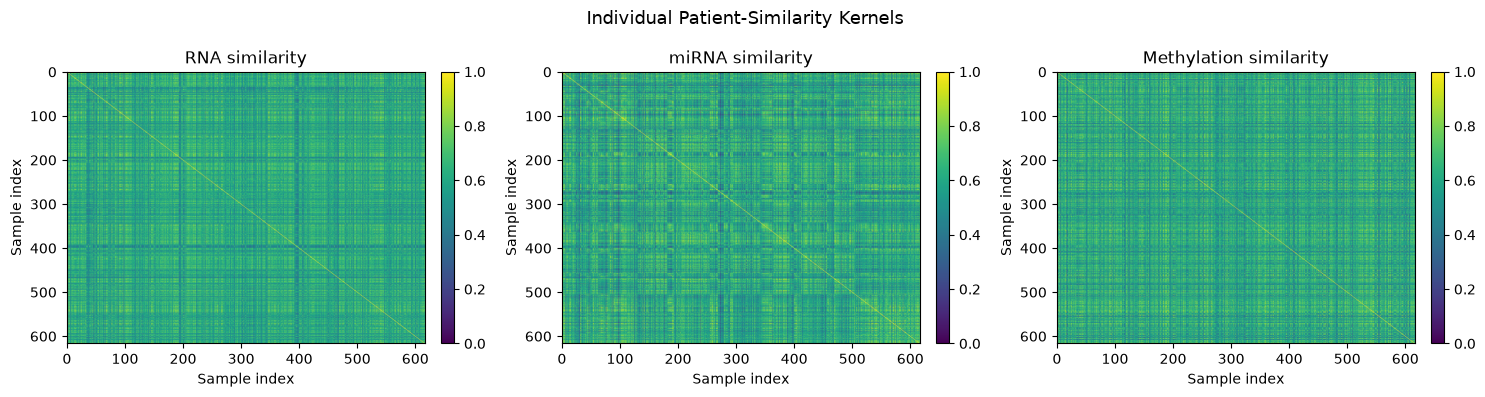

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, kernel) in zip(axes, kernels.items()):
    im = ax.imshow(kernel, cmap="viridis", vmin=0, vmax=1, aspect="auto")
    ax.set_title(f"{name} similarity")
    ax.set_xlabel("Sample index")
    ax.set_ylabel("Sample index")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Individual Patient-Similarity Kernels", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "TCGA_BRCA_individual_kernels.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Integrate the Three Kernels

We use equal-weight **multi-omics kernel integration** for transparency:

$$K_{multi} = \frac{K_{RNA} + K_{miRNA} + K_{methylation}}{3}$$

Each RBF kernel is already on a common diagonal scale ($K_{ii}=1$). We also report trace-normalized kernels as a safeguard against differences in overall kernel magnitude. Equal weighting is intentionally simple; this is **not** an optimized multiple-kernel-learning model.

Integrated kernel shape: (617, 617)
Integrated kernel range: [0.2606, 1.0000]
Integrated diagonal range: [1.0000, 1.0000]


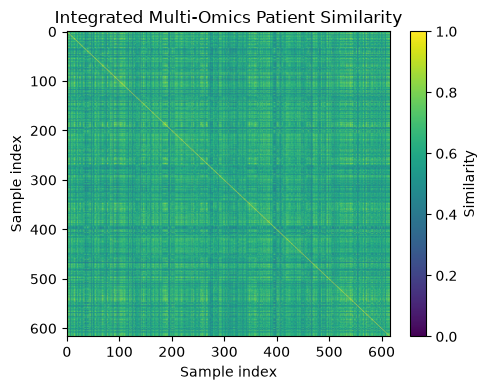

In [6]:
# Trace normalization puts each kernel on the same total self-similarity scale.
normalized_kernels = {
    name: kernel * (len(frozen_ids) / np.trace(kernel))
    for name, kernel in kernels.items()
}
K_multi = sum(normalized_kernels.values()) / len(normalized_kernels)

print(f"Integrated kernel shape: {K_multi.shape}")
print(f"Integrated kernel range: [{K_multi.min():.4f}, {K_multi.max():.4f}]")
print(f"Integrated diagonal range: [{np.diag(K_multi).min():.4f}, {np.diag(K_multi).max():.4f}]")

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(K_multi, cmap="viridis", vmin=0, vmax=1, aspect="auto")
ax.set_title("Integrated Multi-Omics Patient Similarity")
ax.set_xlabel("Sample index"); ax.set_ylabel("Sample index")
plt.colorbar(im, ax=ax, label="Similarity")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "TCGA_BRCA_kernel_multiomics.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Patient Nearest-Neighbor Analysis

For each patient, we identify the five most similar *other* patients using the integrated kernel. The patient's own diagonal similarity is excluded.

In [7]:
K_NEIGHBORS = 5
neighbor_rows = []
for i, sample_id in enumerate(frozen_ids):
    similarity = K_multi[i].copy()
    similarity[i] = -np.inf
    neighbor_indices = np.argsort(similarity)[::-1][:K_NEIGHBORS]
    row = {"sample_id": sample_id, "patient_id": cohort.loc[sample_id, "patient_id"]}
    for rank, j in enumerate(neighbor_indices, start=1):
        row[f"nearest_patient_{rank}"] = cohort.loc[frozen_ids[j], "patient_id"]
        row[f"similarity_{rank}"] = float(K_multi[i, j])
    neighbor_rows.append(row)

neighbors_df = pd.DataFrame(neighbor_rows).set_index("sample_id")
print(neighbors_df.head(10).round(4).to_string())
print(f"\nNearest-neighbor table shape: {neighbors_df.shape}")

                   patient_id nearest_patient_1  similarity_1 nearest_patient_2  similarity_2 nearest_patient_3  similarity_3 nearest_patient_4  similarity_4 nearest_patient_5  similarity_5
sample_id                                                                                                                                                                                    
TCGA-3C-AAAU-01  TCGA-3C-AAAU      TCGA-E9-A1N3        0.7034      TCGA-OL-A66H        0.6705      TCGA-AR-A24L        0.6639      TCGA-E9-A22H        0.6602      TCGA-A7-A3RF        0.6576
TCGA-3C-AALI-01  TCGA-3C-AALI      TCGA-AC-A3W5        0.6893      TCGA-A7-A26J        0.6804      TCGA-A2-A4S3        0.6799      TCGA-AC-A5EH        0.6755      TCGA-D8-A1JC        0.6752
TCGA-3C-AALJ-01  TCGA-3C-AALJ      TCGA-C8-A3M8        0.7462      TCGA-LD-A7W5        0.7309      TCGA-3C-AALK        0.7235      TCGA-EW-A3E8        0.7106      TCGA-C8-A8HQ        0.7082
TCGA-3C-AALK-01  TCGA-3C-AALK      TCGA-EW-A3E8   

---
## 7. Visualize the Integrated Patient-Similarity Structure

KernelPCA operates directly on the integrated precomputed kernel. PAM50 labels are not used to fit the embedding; they are only added to the second panel for interpretation.

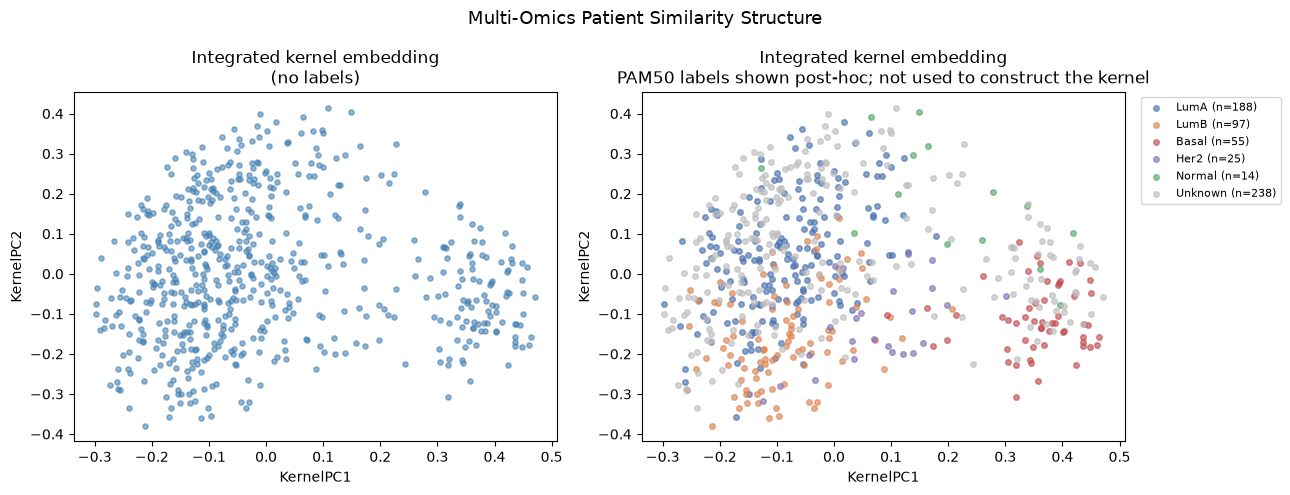

Embedding shape: (617, 2)


In [8]:
kpca = KernelPCA(n_components=2, kernel="precomputed", random_state=SEED)
embedding = kpca.fit_transform(K_multi)
embedding_df = pd.DataFrame(embedding, index=frozen_ids, columns=["PC1", "PC2"])
embedding_df.index.name = "sample_id"

pam50 = cohort["PAM50_subtype"].reindex(frozen_ids).fillna("Unknown")
colors = {
    "LumA": "#4C72B0", "LumB": "#DD8452", "Basal": "#C44E52",
    "Her2": "#8172B3", "Normal": "#55A868", "Unknown": "#BDBDBD",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(embedding[:, 0], embedding[:, 1], s=14, color="steelblue", alpha=0.6)
axes[0].set_title("Integrated kernel embedding\n(no labels)")
axes[0].set_xlabel("KernelPC1"); axes[0].set_ylabel("KernelPC2")

for subtype in ["LumA", "LumB", "Basal", "Her2", "Normal", "Unknown"]:
    mask = pam50.values == subtype
    if mask.any():
        axes[1].scatter(embedding[mask, 0], embedding[mask, 1], s=16,
                        color=colors[subtype], alpha=0.65,
                        label=f"{subtype} (n={mask.sum()})")
axes[1].set_title("Integrated kernel embedding\nPAM50 labels shown post-hoc; not used to construct the kernel")
axes[1].set_xlabel("KernelPC1"); axes[1].set_ylabel("KernelPC2")
axes[1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.suptitle("Multi-Omics Patient Similarity Structure", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "TCGA_BRCA_patient_similarity_embedding.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Embedding shape: {embedding_df.shape}")

---
## 8. Quantitative Post-hoc Interpretation

Using only samples with known PAM50 labels, compare the mean integrated similarity of patients within the same subtype against the mean similarity of patients from different subtypes.

This is an external biological validation of the similarity structure, not a supervised prediction result.

In [9]:
labelled_indices = np.flatnonzero(pam50.values != "Unknown")
K_labelled = K_multi[np.ix_(labelled_indices, labelled_indices)]
labelled_values = pam50.iloc[labelled_indices].values

within_values = []
between_values = []
for i in range(len(labelled_indices)):
    for j in range(i + 1, len(labelled_indices)):
        if labelled_values[i] == labelled_values[j]:
            within_values.append(K_labelled[i, j])
        else:
            between_values.append(K_labelled[i, j])

mean_within = float(np.mean(within_values))
mean_between = float(np.mean(between_values))
print(f"Labelled samples: {len(labelled_indices)}")
print(f"Mean within-subtype similarity : {mean_within:.4f}")
print(f"Mean between-subtype similarity: {mean_between:.4f}")
print(f"Difference (within - between)  : {mean_within - mean_between:.4f}")
print("Interpretation: a positive difference indicates greater similarity within PAM50 subtypes in this cohort.")

Labelled samples: 379
Mean within-subtype similarity : 0.6510
Mean between-subtype similarity: 0.5760
Difference (within - between)  : 0.0750
Interpretation: a positive difference indicates greater similarity within PAM50 subtypes in this cohort.


---
## 9. Optional Sparse Patient-Similarity Network

For a compact visual intuition, we draw only the directed top-5 nearest-neighbour edges per patient. The full 617 × 617 similarity matrix is not converted into a dense network.

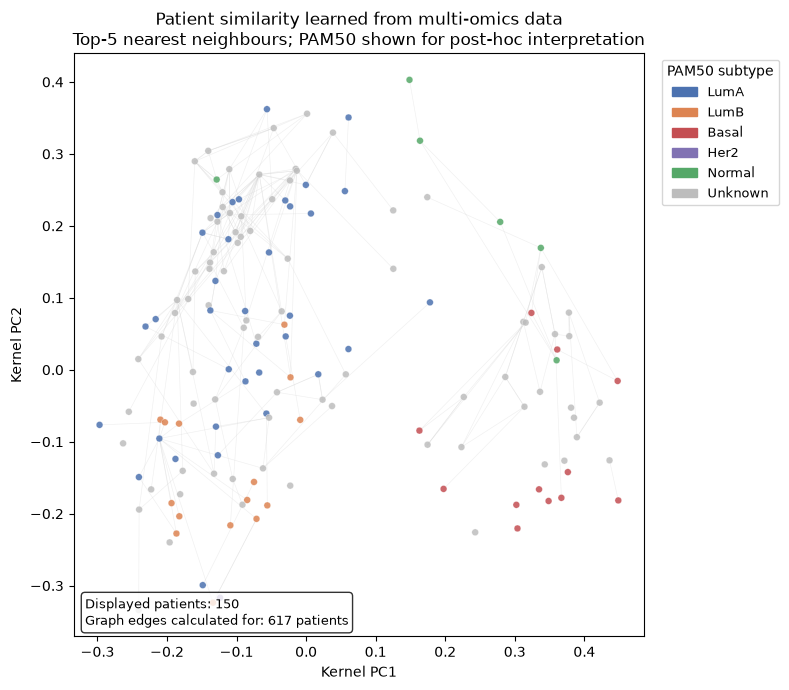

Full graph: 617 patients, 3085 directed edges
Displayed for visualization: 150 patients


In [17]:
# The similarity network is calculated using the complete cohort.
# Only 150 patients are displayed to keep the visualization readable.
subset_n = min(150, len(frozen_ids))
subset_indices = np.arange(subset_n)

# Construct the directed top-k graph for ALL 617 patients.
knn_edges = []
for i in range(len(frozen_ids)):
    similarity = K_multi[i].copy()
    similarity[i] = -np.inf
    for j in np.argsort(similarity)[::-1][:K_NEIGHBORS]:
        knn_edges.append((i, int(j), float(K_multi[i, j])))

fig, ax = plt.subplots(figsize=(8, 7))
# Display only edges whose endpoints are both in the first-150 plotting subset.
for i, j, similarity in knn_edges:
    if i < subset_n and j < subset_n:
        ax.plot([embedding[i, 0], embedding[j, 0]],
                [embedding[i, 1], embedding[j, 1]],
                color="lightgray", linewidth=0.45, alpha=0.35, zorder=1)

node_colors = [colors.get(label, "#BDBDBD") for label in pam50.iloc[:subset_n]]
ax.scatter(embedding[:subset_n, 0], embedding[:subset_n, 1],
           c=node_colors, s=24, alpha=0.85, edgecolor="white",
           linewidth=0.25, zorder=2)

legend_handles = [
    mpatches.Patch(color=colors[label], label=label)
    for label in ["LumA", "LumB", "Basal", "Her2", "Normal", "Unknown"]
    if (pam50.iloc[:subset_n] == label).any()
]
ax.legend(handles=legend_handles, title="PAM50 subtype",
          bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.set_title("Patient similarity learned from multi-omics data\n"
             "Top-5 nearest neighbours; PAM50 shown for post-hoc interpretation",
             fontsize=12)
ax.set_xlabel("Kernel PC1")
ax.set_ylabel("Kernel PC2")
ax.text(0.02, 0.02, f"Displayed patients: {subset_n}\n"
                     f"Graph edges calculated for: {len(frozen_ids)} patients",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
plt.tight_layout()
plt.savefig(FIGURE_DIR / "TCGA_BRCA_patient_similarity_network.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Full graph: {len(frozen_ids)} patients, {len(knn_edges)} directed edges")
print(f"Displayed for visualization: {subset_n} patients")

### How to read the patient-similarity graph

- Nearby points in Kernel PCA space have similar integrated molecular profiles.
- Edges connect each patient to their five most similar other patients; the graph is directed because neighbour relationships need not be reciprocal.
- The similarity network and Kernel PCA coordinates were generated without PAM50. PAM50 colours were added only afterward for interpretation.
- Visually coherent subtype regions would suggest that molecular similarity corresponds to known biology. Overlap is also informative and should not be treated as a modelling failure.

---
## 9. Do Molecularly Similar Patients Tend to Share PAM50 Subtypes?

We evaluate the already constructed **directed top-5 nearest-neighbour graph**. Only directed relationships where both the source patient and the neighbour have known PAM50 labels are included.

The random baseline is the probability that two independently sampled labelled patients share a subtype, calculated from the observed PAM50 class frequencies. This is an exploratory post-hoc comparison, not supervised prediction.

In [18]:
pam50_values = pam50.values
labelled_mask = pam50_values != "Unknown"
labelled_count = int(labelled_mask.sum())

# Evaluate directed edges from the full-cohort graph.
labelled_edges = [
    (source, target)
    for source, target, _ in knn_edges
    if labelled_mask[source] and labelled_mask[target]
]

same_subtype_rate = float(np.mean([
    pam50_values[source] == pam50_values[target]
    for source, target in labelled_edges
]))

labelled_frequencies = pd.Series(pam50_values[labelled_mask]).value_counts(normalize=True)
random_baseline = float((labelled_frequencies ** 2).sum())
enrichment = same_subtype_rate / random_baseline

validation_results = {
    "labelled_patients": labelled_count,
    "labelled_directed_edges": len(labelled_edges),
    "same_subtype_neighbour_rate": same_subtype_rate,
    "random_baseline": random_baseline,
    "enrichment_over_random": enrichment,
}

print("Directed nearest-neighbour validation")
print(f"  PAM50-labelled patients: {labelled_count}")
print(f"  Labelled directed edges: {len(labelled_edges)}")
print(f"  Mean same-subtype neighbour rate: {same_subtype_rate:.4f}")
print(f"  Random baseline: {random_baseline:.4f}")
print(f"  Enrichment over random: {enrichment:.4f}x")

summary_table = pd.DataFrame({
    "Metric": [
        "Patients", "Neighbours per patient", "PAM50-labelled patients",
        "Same-subtype neighbour rate", "Random baseline", "Enrichment",
    ],
    "Result": [
        len(frozen_ids), K_NEIGHBORS, labelled_count,
        f"{same_subtype_rate:.4f}", f"{random_baseline:.4f}", f"{enrichment:.4f}x",
    ],
})
summary_table

Directed nearest-neighbour validation
  PAM50-labelled patients: 379
  Labelled directed edges: 1483
  Mean same-subtype neighbour rate: 0.6730
  Random baseline: 0.3383
  Enrichment over random: 1.9890x


,Metric,Result
0,Patients,617
1,Neighbours per patient,5
2,PAM50-labelled patients,379
3,Same-subtype neighbour rate,0.6730
4,Random baseline,0.3383
5,Enrichment,1.9890x


---
## 10. Save Reproducibility Outputs

The kernel matrices, patient embedding, nearest-neighbour table, figures, and analysis metadata are saved under `data/processed/`. PAM50 is recorded only as a post-hoc reference and was not used to construct any kernel.

In [19]:
kernel_paths = {
    "RNA": PROCESSED_DIR / "TCGA_BRCA_kernel_RNA.tsv",
    "miRNA": PROCESSED_DIR / "TCGA_BRCA_kernel_miRNA.tsv",
    "Methylation": PROCESSED_DIR / "TCGA_BRCA_kernel_methylation.tsv",
}
for name, kernel in kernels.items():
    pd.DataFrame(kernel, index=frozen_ids, columns=frozen_ids).to_csv(
        kernel_paths[name], sep="\t", float_format="%.6f"
    )

pd.DataFrame(K_multi, index=frozen_ids, columns=frozen_ids).to_csv(
    PROCESSED_DIR / "TCGA_BRCA_kernel_multiomics.tsv", sep="\t", float_format="%.6f"
)
embedding_df.to_csv(PROCESSED_DIR / "TCGA_BRCA_patient_similarity_embedding.tsv", sep="\t", float_format="%.6f")
neighbors_df.to_csv(PROCESSED_DIR / "TCGA_BRCA_patient_nearest_neighbors.tsv", sep="\t", float_format="%.6f")

validation_path = PROCESSED_DIR / "TCGA_BRCA_patient_similarity_validation.json"
with open(validation_path, "w") as f:
    json.dump(validation_results, f, indent=2)

metadata = {
    "dataset": "TCGA-BRCA",
    "cohort_size": len(frozen_ids),
    "representation_dimensions": {name: matrix.shape[1] for name, matrix in scaled.items()},
    "representation_total_dimensions": sum(matrix.shape[1] for matrix in scaled.values()),
    "kernel_type": "RBF/Gaussian",
    "gamma_values": {name: float(value) for name, value in gammas.items()},
    "gamma_heuristic": "1 / (2 * median positive squared pairwise distance)",
    "integration_method": "Equal-weight average after trace normalization",
    "nearest_neighbors_k": K_NEIGHBORS,
    "graph_patients": len(frozen_ids),
    "graph_directed_edges": len(knn_edges),
    "displayed_patients": subset_n,
    "pam50_used_during_kernel_construction": False,
    "pam50_role": "Post-hoc external biological interpretation only",
    "labelled_samples_for_interpretation": int((pam50 != "Unknown").sum()),
    "mean_within_subtype_similarity": mean_within,
    "mean_between_subtype_similarity": mean_between,
    "within_between_difference": mean_within - mean_between,
    "same_subtype_neighbour_rate": same_subtype_rate,
    "random_same_subtype_baseline": random_baseline,
    "neighbour_enrichment_over_random": enrichment,
    "selection_note": "No additional feature selection; existing Notebook 1 processed features used",
}
with open(PROCESSED_DIR / "TCGA_BRCA_kernel_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved kernel-analysis outputs:")
for path in list(kernel_paths.values()) + [
    PROCESSED_DIR / "TCGA_BRCA_kernel_multiomics.tsv",
    PROCESSED_DIR / "TCGA_BRCA_patient_similarity_embedding.tsv",
    PROCESSED_DIR / "TCGA_BRCA_patient_nearest_neighbors.tsv",
    validation_path,
    PROCESSED_DIR / "TCGA_BRCA_kernel_metadata.json",
]:
    print(f"  {path.name}: {path.stat().st_size / 1e6:.2f} MB")

Saved kernel-analysis outputs:
  TCGA_BRCA_kernel_RNA.tsv: 3.45 MB
  TCGA_BRCA_kernel_miRNA.tsv: 3.45 MB
  TCGA_BRCA_kernel_methylation.tsv: 3.45 MB
  TCGA_BRCA_kernel_multiomics.tsv: 3.45 MB
  TCGA_BRCA_patient_similarity_embedding.tsv: 0.02 MB
  TCGA_BRCA_patient_nearest_neighbors.tsv: 0.09 MB
  TCGA_BRCA_patient_similarity_validation.json: 0.00 MB
  TCGA_BRCA_kernel_metadata.json: 0.00 MB


---
## 11. Final Validation

The checks below confirm the kernel dimensions, numerical validity, cohort ordering, neighbour table, and embedding size.

In [20]:
checks = {
    "RNA kernel is 617 × 617": kernels["RNA"].shape == (617, 617),
    "miRNA kernel is 617 × 617": kernels["miRNA"].shape == (617, 617),
    "Methylation kernel is 617 × 617": kernels["Methylation"].shape == (617, 617),
    "Integrated kernel is 617 × 617": K_multi.shape == (617, 617),
    "Kernel diagonals approximately 1": np.allclose(np.diag(K_multi), 1.0, atol=1e-5),
    "Integrated kernel has no NaN/inf": np.isfinite(K_multi).all(),
    "Sample order matches frozen cohort": list(rna.index) == frozen_ids,
    "Nearest-neighbor table has 617 rows": len(neighbors_df) == 617,
    "Embedding has 617 rows": len(embedding_df) == 617,
}
for description, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL':>4}: {description}")
assert all(checks.values()), "One or more final validation checks failed."
print("\nAll final validation checks passed.")

PASS: RNA kernel is 617 × 617
PASS: miRNA kernel is 617 × 617
PASS: Methylation kernel is 617 × 617
PASS: Integrated kernel is 617 × 617
PASS: Kernel diagonals approximately 1
PASS: Integrated kernel has no NaN/inf
PASS: Sample order matches frozen cohort
PASS: Nearest-neighbor table has 617 rows
PASS: Embedding has 617 rows

All final validation checks passed.


---
## 12. Workshop Takeaway

> Kernel methods provide a flexible way to compare patients based on nonlinear molecular relationships. By constructing and integrating similarity kernels from multiple omics layers, we obtain a patient-level representation that can reveal molecularly similar groups without directly training a classifier.

**Key idea:**

`Features → pairwise similarities → integrated patient representation`

**Limitation:** The equal-weight kernel integration used here is intentionally simple. In a full analysis, kernel weights and similarity parameters could be learned or optimised.

This notebook demonstrates a complete mini-analysis:

`LOAD → PREPROCESS → KERNELS → INTEGRATE → PATIENT SIMILARITY → VISUALISE → INTERPRET → SAVE`

In [21]:
# ── Final workshop report ─────────────────────────────────────────────────────
output_files = [
    *kernel_paths.values(),
    PROCESSED_DIR / "TCGA_BRCA_kernel_multiomics.tsv",
    PROCESSED_DIR / "TCGA_BRCA_patient_similarity_embedding.tsv",
    PROCESSED_DIR / "TCGA_BRCA_patient_nearest_neighbors.tsv",
    PROCESSED_DIR / "TCGA_BRCA_patient_similarity_validation.json",
    PROCESSED_DIR / "TCGA_BRCA_kernel_metadata.json",
    FIGURE_DIR / "TCGA_BRCA_individual_kernels.png",
    FIGURE_DIR / "TCGA_BRCA_kernel_multiomics.png",
    FIGURE_DIR / "TCGA_BRCA_patient_similarity_embedding.png",
    FIGURE_DIR / "TCGA_BRCA_patient_similarity_network.png",
]

print("=" * 65)
print("  FINAL PATIENT-SIMILARITY REPORT")
print("=" * 65)
print(f"  Cohort size                 : {len(frozen_ids)} patients")
print(f"  Representation dimensions  : {sum(matrix.shape[1] for matrix in scaled.values())} "
      f"({', '.join(f'{name}={matrix.shape[1]}' for name, matrix in scaled.items())})")
print("  Similarity metric           : RBF/Gaussian kernel")
print(f"  Neighbours per patient     : {K_NEIGHBORS}")
print(f"  Displayed patients         : {subset_n} (visualization only)")
print(f"  PAM50-labelled patients    : {labelled_count}")
print(f"  Same-subtype neighbour rate: {same_subtype_rate:.4f}")
print(f"  Random baseline            : {random_baseline:.4f}")
print(f"  Enrichment                 : {enrichment:.4f}x")
print("  PAM50 role                 : post-hoc interpretation only")
print("\n  Output files created:")
for path in output_files:
    print(f"    {path.relative_to(PROJECT_DIR)}")
print("=" * 65)

  FINAL PATIENT-SIMILARITY REPORT
  Cohort size                 : 617 patients
  Representation dimensions  : 2300 (RNA=1000, miRNA=300, Methylation=1000)
  Similarity metric           : RBF/Gaussian kernel
  Neighbours per patient     : 5
  Displayed patients         : 150 (visualization only)
  PAM50-labelled patients    : 379
  Same-subtype neighbour rate: 0.6730
  Random baseline            : 0.3383
  Enrichment                 : 1.9890x
  PAM50 role                 : post-hoc interpretation only

  Output files created:
    data\processed\TCGA_BRCA_kernel_RNA.tsv
    data\processed\TCGA_BRCA_kernel_miRNA.tsv
    data\processed\TCGA_BRCA_kernel_methylation.tsv
    data\processed\TCGA_BRCA_kernel_multiomics.tsv
    data\processed\TCGA_BRCA_patient_similarity_embedding.tsv
    data\processed\TCGA_BRCA_patient_nearest_neighbors.tsv
    data\processed\TCGA_BRCA_patient_similarity_validation.json
    data\processed\TCGA_BRCA_kernel_metadata.json
    data\processed\figures\TCGA_BRCA_indi